In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os, random, cv2, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet169, ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

2026-04-28 08:26:15.227169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777364775.434173      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777364775.496335      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777364776.002678      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777364776.002716      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777364776.002719      55 computation_placer.cc:177] computation placer alr

In [3]:
class CFG:
    DATA_DIR = "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
    CLASSES = ['benign','malignant','normal']

    IMG_SIZE = 224
    BATCH = 16
    EPOCHS = 40
    LR = 1e-4

In [4]:
def load_df():
    data=[]
    for c in CFG.CLASSES:
        folder=os.path.join(CFG.DATA_DIR,c)
        for f in os.listdir(folder):
            if "_mask" not in f:
                data.append([os.path.join(folder,f),c])
    return pd.DataFrame(data,columns=['path','label'])

df=load_df()

In [5]:
train_df, temp = train_test_split(df, test_size=0.3,
                                  stratify=df['label'], random_state=SEED)

val_df, test_df = train_test_split(temp, test_size=0.5,
                                   stratify=temp['label'], random_state=SEED)

In [6]:
def preprocess(path):
    img=cv2.imread(path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    lab=cv2.cvtColor(img,cv2.COLOR_RGB2LAB)
    l,a,b=cv2.split(lab)
    clahe=cv2.createCLAHE(2.0,(8,8))
    l=clahe.apply(l)
    img=cv2.merge((l,a,b))
    img=cv2.cvtColor(img,cv2.COLOR_LAB2RGB)

    img=cv2.resize(img,(CFG.IMG_SIZE,CFG.IMG_SIZE))
    return img/255.0

In [7]:
class Gen(tf.keras.utils.Sequence):
    def __init__(self, df, aug=False):
        self.df=df.reset_index(drop=True)
        self.aug=aug
        self.map={c:i for i,c in enumerate(CFG.CLASSES)}

    def __len__(self):
        return int(math.ceil(len(self.df)/CFG.BATCH))

    def __getitem__(self,i):
        batch=self.df.iloc[i*CFG.BATCH:(i+1)*CFG.BATCH]
        X,Y=[],[]

        for _,r in batch.iterrows():
            img=preprocess(r['path'])

            if self.aug:
                if random.random()<0.5: img=np.fliplr(img)
                if random.random()<0.5: img=np.flipud(img)

            X.append(img)
            Y.append(self.map[r['label']])

        return np.array(X), tf.keras.utils.to_categorical(Y,3)

train_gen=Gen(train_df,True)
val_gen=Gen(val_df)
test_gen=Gen(test_df)

In [8]:
labels=train_df['label'].map({c:i for i,c in enumerate(CFG.CLASSES)})
cw=compute_class_weight('balanced', classes=np.unique(labels), y=labels)
cw=dict(enumerate(cw))

In [9]:
def transformer_block(x):
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x,x)
    x = layers.Add()([x,attn])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(128, activation='gelu')(x)
    ffn = layers.Dense(x.shape[-1])(ffn)

    x = layers.Add()([x,ffn])
    x = layers.LayerNormalization()(x)
    return x

def attention_fusion(x):
    attn = layers.Dense(x.shape[-1], activation='sigmoid')(x)
    return layers.Multiply()([x,attn])

def build_model():
    inp = layers.Input((224,224,3))

    def cnn(m):
        m.trainable=False
        x=m(inp,training=False)
        return layers.GlobalAveragePooling2D()(x)

    b1=cnn(DenseNet169(weights='imagenet',include_top=False))
    b2=cnn(ResNet50(weights='imagenet',include_top=False))

    cnn_feat=layers.Concatenate()([b1,b2])

    # ViT
    x = layers.Conv2D(64,16,16)(inp)
    x = layers.Reshape((-1,64))(x)

    for _ in range(4):
        x=transformer_block(x)

    vit_feat = layers.GlobalAveragePooling1D()(x)

    x = layers.Concatenate()([cnn_feat,vit_feat])
    x = attention_fusion(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dense(512,activation='swish')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256,activation='swish')(x)
    x = layers.Dropout(0.4)(x)

    out = layers.Dense(3,activation='softmax')(x)

    model=Model(inp,out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(CFG.LR),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy',tf.keras.metrics.AUC()]
    )

    return model

model=build_model()

I0000 00:00:1777364801.386195      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777364801.392634      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
callbacks=[
    tf.keras.callbacks.EarlyStopping(patience=8,restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=4)
]

history=model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=CFG.EPOCHS,
    class_weight=cw,
    callbacks=callbacks
)

Epoch 1/40


I0000 00:00:1777364840.547637     127 service.cc:152] XLA service 0x78483c047830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777364840.547689     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777364840.547695     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777364848.715703     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/35 ━━━━━━━━━━━━━━━━━━━━ 36:09 64s/step - accuracy: 0.1875 - auc: 0.3398 - loss: 1.2426

I0000 00:00:1777364872.850150     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.3391 - auc: 0.5294 - loss: 1.1215 - val_accuracy: 0.6239 - val_auc: 0.7978 - val_loss: 0.9935 - learning_rate: 1.0000e-04
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 315ms/step - accuracy: 0.5243 - auc: 0.7269 - loss: 0.9086 - val_accuracy: 0.6667 - val_auc: 0.8591 - val_loss: 0.9605 - learning_rate: 1.0000e-04
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - accuracy: 0.6714 - auc: 0.8494 - loss: 0.7698 - val_accuracy: 0.7607 - val_auc: 0.8964 - val_loss: 0.9368 - learning_rate: 1.0000e-04
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 312ms/step - accuracy: 0.6768 - auc: 0.8570 - loss: 0.7355 - val_accuracy: 0.7863 - val_auc: 0.9123 - val_loss: 0.8951 - learning_rate: 1.0000e-04
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 315ms/step - accuracy: 0.7209 - auc: 0.9045 - loss: 0.7024 - val_accuracy: 0.7949 - val_auc: 0.9230 - val_loss: 0.8511 - learning_rate: 1.0000e-04
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.7

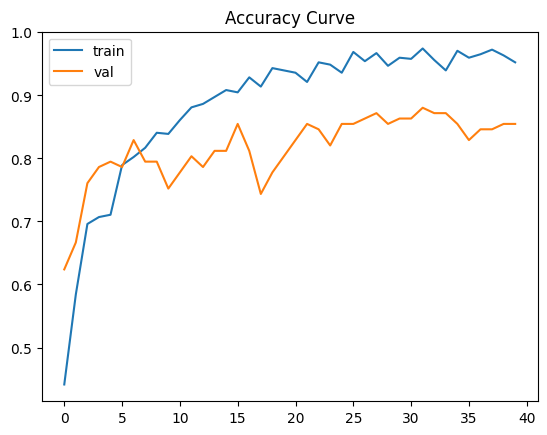

In [11]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [12]:
y_true,y_pred,y_prob=[],[],[]

for i in range(len(test_gen)):
    X,Y=test_gen[i]
    p=model.predict(X,verbose=0)

    y_true+=list(np.argmax(Y,1))
    y_pred+=list(np.argmax(p,1))
    y_prob+=list(p)

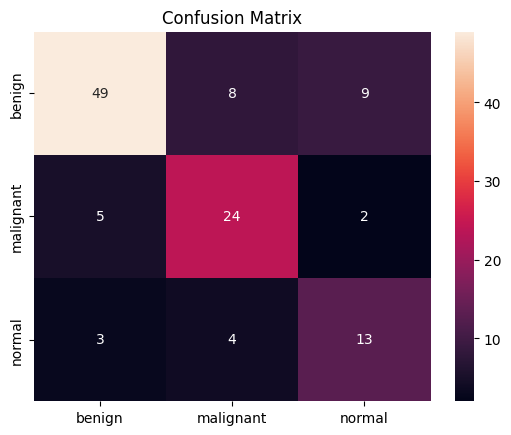

In [13]:
cm=confusion_matrix(y_true,y_pred)

sns.heatmap(cm,annot=True,fmt='d',
            xticklabels=CFG.CLASSES,
            yticklabels=CFG.CLASSES)
plt.title("Confusion Matrix")
plt.show()

In [14]:
print(classification_report(y_true,y_pred,target_names=CFG.CLASSES))

              precision    recall  f1-score   support

      benign       0.86      0.74      0.80        66
   malignant       0.67      0.77      0.72        31
      normal       0.54      0.65      0.59        20

    accuracy                           0.74       117
   macro avg       0.69      0.72      0.70       117
weighted avg       0.75      0.74      0.74       117



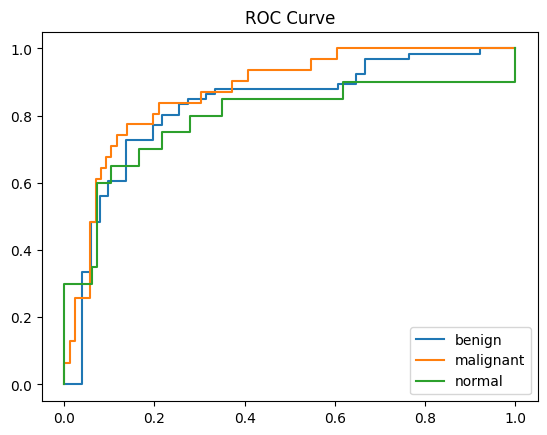

In [15]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_prob = np.array(y_prob)

for i in range(3):
    fpr,tpr,_=roc_curve(y_true_bin[:,i],y_prob[:,i])
    plt.plot(fpr,tpr,label=CFG.CLASSES[i])

plt.legend()
plt.title("ROC Curve")
plt.show()

In [16]:
def gradcam(img):
    last_conv = model.layers[-10]

    grad_model = Model(model.inputs,
                       [last_conv.output, model.output])

    with tf.GradientTape() as tape:
        conv_out,pred=grad_model(img)
        loss=pred[:,np.argmax(pred[0])]

    grads=tape.gradient(loss,conv_out)
    heatmap=tf.reduce_mean(grads,axis=(0,1,2))

    heatmap=np.maximum(heatmap,0)/np.max(heatmap)
    return heatmap